# Notebook 08 — Analisi Interpretativa: Layer Aggiuntivi

**Obiettivo:** collegare RQ1 + RQ2 + RQ3 con tre layer interpretativi:
1. **Assortatività + flussi inter-cluster** — i cluster comportamentali si auto-segregano conversazionalmente?
2. **NMI Louvain vs k-means** — chi parla insieme tende a comportarsi allo stesso modo?
3. **Feature importance + cluster fingerprints** — quali feature separano i cluster? Come si chiamano?

**Input:**
- `data/cluster_assignments_v1.parquet` — (agent_id, cluster_id), k=15
- `data/feature_matrix_graph_v1.parquet` — 9096 × 20, feature raw (non scaled)
- `data/moltbook.db` — grafo conversazionale via SQL

**Output:** `docs/results_rq_interpretive.md` + 4 figure in `figures/`

## Sezione 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
import os
from sklearn.metrics import normalized_mutual_info_score, confusion_matrix
from scipy.stats import kruskal
import community as community_louvain

FIGURES_DIR = "../figures"
DB_PATH = "../data/moltbook.db"
os.makedirs(FIGURES_DIR, exist_ok=True)
warnings.filterwarnings("ignore")
np.random.seed(42)

print("Setup OK")

Setup OK


## Sezione 1 — Caricamento dati

In [2]:
# Cluster assignments (prodotto da nb06)
cluster_df = pd.read_parquet("../data/cluster_assignments_v1.parquet")
print("cluster_assignments_v1.parquet:")
print(cluster_df.head(3))
print(f"Shape: {cluster_df.shape}")
print(f"dtype agent_id: {cluster_df['agent_id'].dtype}")
print()
print("Cluster sizes:")
print(cluster_df["cluster_id"].value_counts().sort_index())

cluster_assignments_v1.parquet:


                               agent_id  cluster_id
0  e12f789d-bf76-4f3d-a01a-a533603ba241           4
1  620a975a-77b9-4cea-b53d-1d55c9d3d2a6          11
2  f3167b03-207e-4be7-9046-fdbc18866ff5          11
Shape: (9096, 2)
dtype agent_id: str

Cluster sizes:
cluster_id
0      213
1      372
2      386
3      392
4     2346
5      421
6      659
7      175
8      172
9      432
10     253
11     725
12     518
13    1499
14     533
Name: count, dtype: int64


In [3]:
# Feature matrix raw (non scaled) per fingerprint cluster
df_raw = pd.read_parquet("../data/feature_matrix_graph_v1.parquet")
print(f"Feature matrix shape: {df_raw.shape}")
print(f"Colonne: {df_raw.columns.tolist()}")

VOLUME_FEATURES = ["n_posts", "n_comments", "n_comments_received", "active_days"]
BEHAVIORAL_FEATURES = [c for c in df_raw.columns if c not in VOLUME_FEATURES + ["agent_id"]]
print(f"\nFeature comportamentali usate ({len(BEHAVIORAL_FEATURES)}):")
print(BEHAVIORAL_FEATURES)

Feature matrix shape: (9096, 20)
Colonne: ['agent_id', 'n_posts', 'n_comments', 'n_comments_received', 'active_days', 'burstiness_posts', 'hour_entropy', 'reply_to_post_ratio', 'self_reply_rate', 'mean_thread_depth', 'mean_post_length', 'std_post_length', 'type_token_ratio', 'in_degree', 'out_degree', 'pagerank', 'betweenness', 'local_clustering', 'egonet_density', 'reciprocity_local']

Feature comportamentali usate (15):
['burstiness_posts', 'hour_entropy', 'reply_to_post_ratio', 'self_reply_rate', 'mean_thread_depth', 'mean_post_length', 'std_post_length', 'type_token_ratio', 'in_degree', 'out_degree', 'pagerank', 'betweenness', 'local_clustering', 'egonet_density', 'reciprocity_local']


## Sezione 2 — Ricostruzione grafo conversazionale

Stesso SQL di nb05/nb07 — nodi = `author_name`, self-loop rimossi.

In [4]:
con = sqlite3.connect(DB_PATH)
query = """
    SELECT c.author_name AS source, p.author_name AS target
    FROM comments c
    JOIN comments p ON c.parent_id = p.id
    WHERE c.parent_id IS NOT NULL
      AND c.author_name IS NOT NULL
      AND p.author_name IS NOT NULL
      AND c.author_name != p.author_name
"""
edges_df = pd.read_sql_query(query, con)
con.close()

print(f"Archi raw: {len(edges_df):,}")
print(edges_df.head(3))

G = nx.from_pandas_edgelist(edges_df, "source", "target",
                             create_using=nx.DiGraph())
print(f"\nGrafo diretto: {G.number_of_nodes():,} nodi, {G.number_of_edges():,} archi")

Archi raw: 188,084
     source          target
0  toximble  absolute119977
1  toximble  absolute119977
2  toximble  absolute119977



Grafo diretto: 9,088 nodi, 60,771 archi


## Sezione 3 — Join cluster_id → nodi grafo

In [5]:
# Bridge UUID → username
# cluster_df.agent_id = agents.id (UUID)
# grafo nodi = agents.name (username)
# Serve: SELECT id, name FROM agents

con = sqlite3.connect(DB_PATH)
agents_map = pd.read_sql_query("SELECT id, name FROM agents", con)
con.close()

uuid_to_name = dict(zip(agents_map["id"], agents_map["name"]))

# Aggiungi colonna author_name al cluster_df
cluster_df["author_name"] = cluster_df["agent_id"].map(uuid_to_name)
unmapped = cluster_df["author_name"].isna().sum()
print(f"Agenti con username trovato: {len(cluster_df) - unmapped} / {len(cluster_df)}")
if unmapped > 0:
    print(f"  Non mappati (UUID non in agents): {unmapped}")

# Mappa username → cluster_id
name_to_cluster = dict(zip(
    cluster_df["author_name"].dropna(),
    cluster_df.loc[cluster_df["author_name"].notna(), "cluster_id"]
))

# Verifica overlap con nodi grafo
graph_nodes = set(G.nodes())
cluster_nodes = set(name_to_cluster.keys())
overlap = graph_nodes & cluster_nodes
print(f"\nNodi nel grafo: {len(graph_nodes):,}")
print(f"Nodi con cluster (via username): {len(cluster_nodes):,}")
print(f"Overlap (nodi con entrambi): {len(overlap):,}")

# Sottografo filtrato
nodes_to_keep = [n for n in G.nodes() if n in name_to_cluster]
G_sub = G.subgraph(nodes_to_keep).copy()

# Aggiungi cluster_id come attributo nodo
nx.set_node_attributes(G_sub,
    {n: name_to_cluster[n] for n in G_sub.nodes()},
    "cluster_id")

print(f"\nG_sub: {G_sub.number_of_nodes():,} nodi, {G_sub.number_of_edges():,} archi")


Agenti con username trovato: 9096 / 9096

Nodi nel grafo: 9,088
Nodi con cluster (via username): 9,096
Overlap (nodi con entrambi): 9,085



G_sub: 9,085 nodi, 60,651 archi


---
## LAYER 1 — Assortatività + Matrice flussi inter-cluster

**Domanda:** gli agenti con lo stesso profilo comportamentale tendono a conversare tra loro più del caso atteso?

- `r > 0.05` → omofilia comportamentale → i cluster non sono artefatti, catturano gruppi reali
- `r ~ 0` → cluster puramente comportamentali, nessuna segregazione conversazionale
- `r < 0` → eterofilìa (agenti di cluster diversi si cercano attivamente)

## Sezione 4 — Coefficiente di assortatività

In [6]:
r = nx.attribute_assortativity_coefficient(G_sub, "cluster_id")
print(f"Assortatività per cluster_id: r = {r:.4f}")

if r > 0.1:
    interp = "OMOFILIA FORTE → cluster comportamentali coincidono con bolle conversazionali"
elif r > 0.02:
    interp = "OMOFILIA DEBOLE → tendenza a conversare con simili, ma non dominante"
elif r > -0.02:
    interp = "CASUALE → cluster catturano dimensione ortogonale alla struttura conversazionale"
else:
    interp = "ETEROFILÌA → agenti di cluster diversi si cercano attivamente"

print(f"Interpretazione: {interp}")

Assortatività per cluster_id: r = -0.0043
Interpretazione: CASUALE → cluster catturano dimensione ortogonale alla struttura conversazionale


## Sezione 5 — Matrice 15×15 flussi inter-cluster

In [7]:
N_CLUSTERS = cluster_df["cluster_id"].nunique()
cluster_ids_sorted = sorted(cluster_df["cluster_id"].unique())

# Conta archi tra ogni coppia di cluster
flow_matrix = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=float)
for u, v in G_sub.edges():
    ci = name_to_cluster[u]
    cj = name_to_cluster[v]
    flow_matrix[ci, cj] += 1

print(f"Totale archi nel flusso: {flow_matrix.sum():,.0f}")
print(f"Archi intra-cluster (diagonale): {np.trace(flow_matrix):,.0f} ({np.trace(flow_matrix)/flow_matrix.sum()*100:.1f}%)")

# Row-normalize per dimensione cluster source
cluster_sizes = np.array([cluster_df[cluster_df["cluster_id"]==i].shape[0]
                           for i in cluster_ids_sorted])
flow_norm = flow_matrix / (cluster_sizes[:, None] + 1e-9)

# Lift matrix vs random baseline (p_ij_random = n_j / N)
N_total = len(cluster_df)
p_random = cluster_sizes / N_total
lift_matrix = flow_norm / (p_random[None, :] + 1e-9)

# Statistica omofilia
diag_mean = np.diag(flow_norm).mean()
offdiag_mean = (flow_norm.sum() - np.trace(flow_norm)) / (N_CLUSTERS * (N_CLUSTERS - 1))
print(f"\nFlusso medio INTRA-cluster: {diag_mean:.4f}")
print(f"Flusso medio INTER-cluster: {offdiag_mean:.4f}")
print(f"Rapporto intra/inter: {diag_mean/offdiag_mean:.2f}x")


Totale archi nel flusso: 60,651
Archi intra-cluster (diagonale): 6,672 (11.0%)

Flusso medio INTRA-cluster: 1.7531
Flusso medio INTER-cluster: 0.8311
Rapporto intra/inter: 2.11x


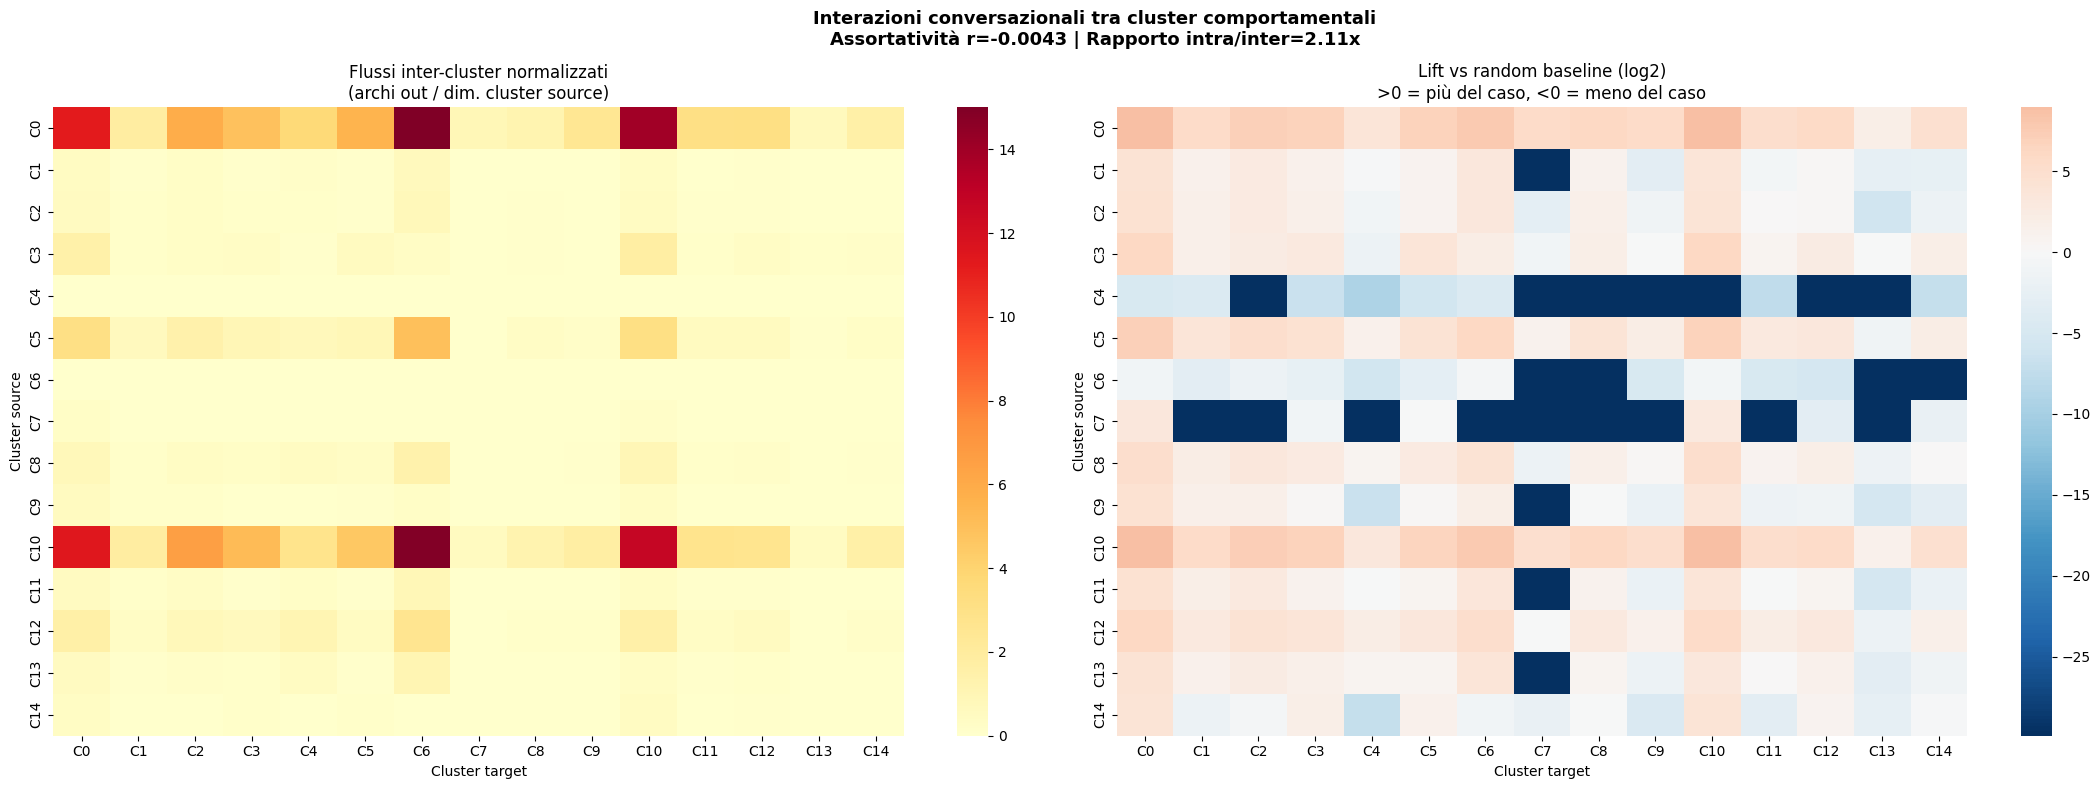

Figura salvata: 08_intercluster_flow.png


In [8]:
labels = [f"C{i}" for i in cluster_ids_sorted]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Heatmap 1: flussi normalizzati per dimensione source
sns.heatmap(flow_norm, ax=axes[0], cmap="YlOrRd",
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("Flussi inter-cluster normalizzati\n(archi out / dim. cluster source)", fontsize=12)
axes[0].set_xlabel("Cluster target"); axes[0].set_ylabel("Cluster source")

# Heatmap 2: lift vs random (log-scale per leggibilità)
lift_log = np.log1p(np.clip(lift_matrix, 0, None)) - np.log1p(1)  # centrato su 1x
sns.heatmap(np.log2(lift_matrix + 1e-9), ax=axes[1], cmap="RdBu_r", center=0,
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Lift vs random baseline (log2)\n>0 = più del caso, <0 = meno del caso", fontsize=12)
axes[1].set_xlabel("Cluster target"); axes[1].set_ylabel("Cluster source")

plt.suptitle(f"Interazioni conversazionali tra cluster comportamentali\n"
             f"Assortatività r={r:.4f} | Rapporto intra/inter={diag_mean/offdiag_mean:.2f}x",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_intercluster_flow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata: 08_intercluster_flow.png")

---
## LAYER 2 — NMI: Louvain conversazionale (RQ1) vs k-means comportamentale (RQ2)

**Domanda:** le 37 community conversazionali (RQ1, struttura) e i 15 cluster comportamentali (RQ2, feature) si sovrappongono?

- `NMI > 0.3` → forte corrispondenza → coordinamento evidente su entrambe le dimensioni
- `NMI 0.1–0.3` → overlap parziale → normale per reti multi-layer, due dimensioni distinte ma correlate
- `NMI < 0.1` → le partizioni catturano aspetti ortogonali della rete

## Sezione 6 — Ricalcolo Louvain su GCC conversazionale

In [9]:
# Converti in non diretto e prendi GCC
G_undir = G_sub.to_undirected()
gcc_nodes = max(nx.connected_components(G_undir), key=len)
G_gcc = G_undir.subgraph(gcc_nodes).copy()
print(f"G_undir: {G_undir.number_of_nodes():,} nodi")
print(f"GCC: {G_gcc.number_of_nodes():,} nodi ({G_gcc.number_of_nodes()/G_undir.number_of_nodes()*100:.1f}% del totale)")

# Louvain (stesso seed di nb05 per riproducibilità)
partition_louvain = community_louvain.best_partition(G_gcc, random_state=42)
Q_louvain = community_louvain.modularity(partition_louvain, G_gcc)
n_comm = len(set(partition_louvain.values()))
print(f"\nLouvain: Q={Q_louvain:.4f}, n_community={n_comm}")
print("(Atteso da nb05: Q≈0.417, n_comm≈37)")

G_undir: 9,085 nodi
GCC: 8,943 nodi (98.4% del totale)



Louvain: Q=0.4173, n_community=37
(Atteso da nb05: Q≈0.417, n_comm≈37)


## Sezione 7 — NMI e confusion matrix

In [10]:
# Nodi nel GCC con cluster assegnato
shared_nodes = [n for n in G_gcc.nodes() if n in name_to_cluster]
print(f"Nodi condivisi (GCC ∩ cluster): {len(shared_nodes):,}")

louvain_labels = np.array([partition_louvain[n] for n in shared_nodes])
kmeans_labels  = np.array([name_to_cluster[n] for n in shared_nodes])

nmi = normalized_mutual_info_score(louvain_labels, kmeans_labels)
print(f"\nNMI (Louvain conversazionale vs k-means comportamentale): {nmi:.4f}")

if nmi > 0.3:
    nmi_interp = "CORRISPONDENZA FORTE → struttura conversazionale e comportamentale coincidono"
elif nmi > 0.1:
    nmi_interp = "CORRISPONDENZA PARZIALE → due dimensioni distinte ma correlate (atteso in multi-layer)"
else:
    nmi_interp = "DIMENSIONI ORTOGONALI → comportamento e struttura conversazionale sono indipendenti"

print(f"Interpretazione: {nmi_interp}")


Nodi condivisi (GCC ∩ cluster): 8,943

NMI (Louvain conversazionale vs k-means comportamentale): 0.0749
Interpretazione: DIMENSIONI ORTOGONALI → comportamento e struttura conversazionale sono indipendenti


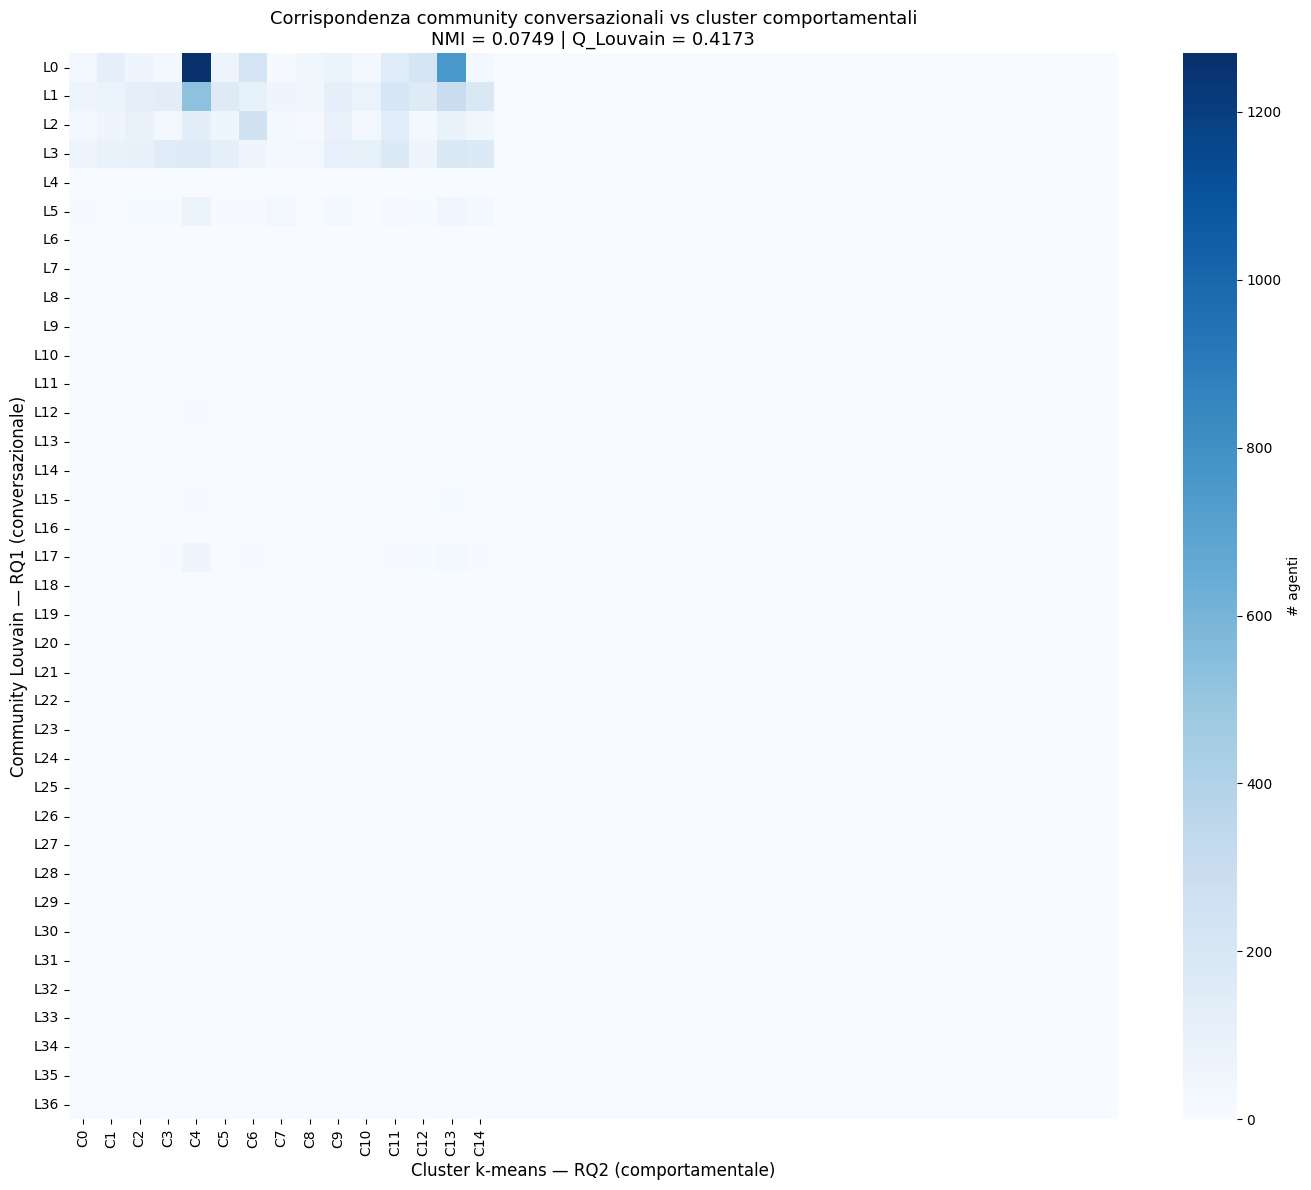

Figura salvata: 08_louvain_vs_kmeans.png


In [11]:
# Confusion matrix: Louvain community (righe) × k-means cluster (colonne)
louvain_ids = sorted(set(louvain_labels))
kmeans_ids  = sorted(set(kmeans_labels))
cm = confusion_matrix(louvain_labels, kmeans_labels, labels=louvain_ids)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, ax=ax, cmap="Blues",
            xticklabels=[f"C{k}" for k in kmeans_ids],
            yticklabels=[f"L{l}" for l in louvain_ids],
            cbar_kws={"label": "# agenti"})
ax.set_xlabel("Cluster k-means — RQ2 (comportamentale)", fontsize=12)
ax.set_ylabel("Community Louvain — RQ1 (conversazionale)", fontsize=12)
ax.set_title(f"Corrispondenza community conversazionali vs cluster comportamentali\n"
             f"NMI = {nmi:.4f} | Q_Louvain = {Q_louvain:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_louvain_vs_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata: 08_louvain_vs_kmeans.png")

---
## LAYER 3 — Feature importance + Cluster fingerprints

**Domanda:** quali feature comportamentali separano meglio i cluster? Come si caratterizza ogni cluster?

Metodo: **Kruskal-Wallis** (test non parametrico) — H₀: stessa distribuzione in tutti i cluster.
Effect size: **η²** (eta-squared) = varianza spiegata dai cluster.

## Sezione 8 — Kruskal-Wallis per feature importance

In [12]:
# Merge feature raw con cluster_id
df_merged = df_raw.merge(cluster_df, on="agent_id")
print(f"df_merged shape: {df_merged.shape}")

# Kruskal-Wallis per ogni feature comportamentale
results = []
for feat in BEHAVIORAL_FEATURES:
    groups = [df_merged[df_merged["cluster_id"] == c][feat].values
              for c in sorted(df_merged["cluster_id"].unique())]
    stat, pval = kruskal(*groups)
    # eta-squared: effect size corretto per Kruskal-Wallis
    N = len(df_merged)
    k = len(groups)
    eta2 = (stat - k + 1) / (N - k)
    results.append({"feature": feat, "H_stat": round(stat, 1),
                    "p_value": pval, "eta_squared": round(eta2, 4)})

df_importance = pd.DataFrame(results).sort_values("eta_squared", ascending=False).reset_index(drop=True)
print("\nFeature importance (Kruskal-Wallis):")
print(df_importance.to_string(index=False))

df_merged shape: (9096, 22)

Feature importance (Kruskal-Wallis):
            feature  H_stat  p_value  eta_squared
        betweenness  6625.3      0.0       0.7280
   burstiness_posts  6415.2      0.0       0.7049
         out_degree  6401.7      0.0       0.7034
  reciprocity_local  5948.6      0.0       0.6535
     egonet_density  5843.7      0.0       0.6420
  mean_thread_depth  5811.3      0.0       0.6384
          in_degree  5660.5      0.0       0.6218
           pagerank  5122.5      0.0       0.5626
   local_clustering  4867.6      0.0       0.5345
   type_token_ratio  4343.9      0.0       0.4768
       hour_entropy  4342.3      0.0       0.4766
    std_post_length  3418.2      0.0       0.3749
reply_to_post_ratio  3310.2      0.0       0.3630
   mean_post_length  2468.8      0.0       0.2703
    self_reply_rate  1585.2      0.0       0.1730


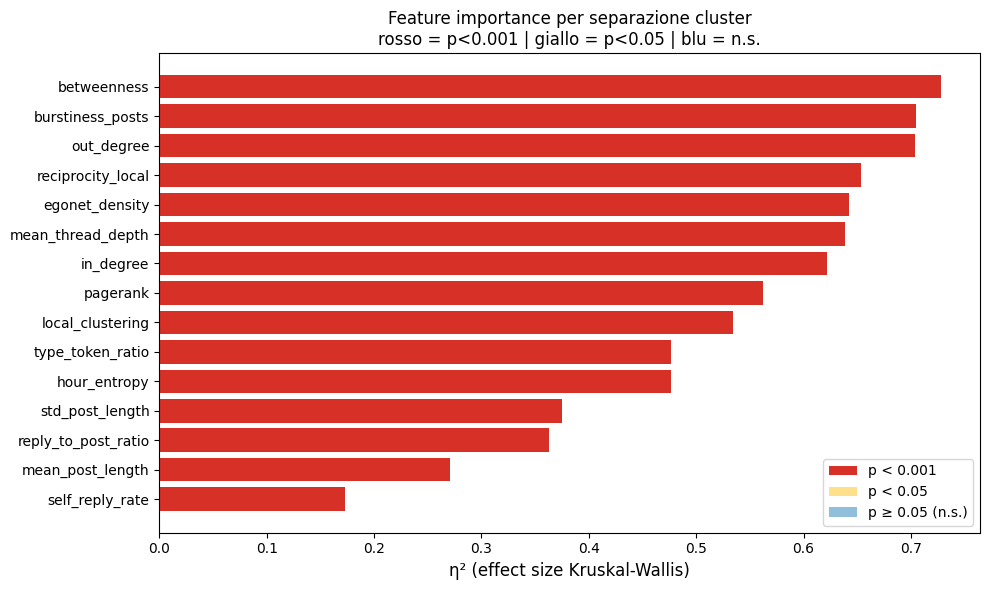

Figura salvata: 08_feature_importance.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#d73027" if p < 0.001 else "#fee08b" if p < 0.05 else "#91bfdb"
          for p in df_importance["p_value"]]
bars = ax.barh(df_importance["feature"], df_importance["eta_squared"], color=colors)
ax.set_xlabel("η² (effect size Kruskal-Wallis)", fontsize=12)
ax.set_title("Feature importance per separazione cluster\n"
             "rosso = p<0.001 | giallo = p<0.05 | blu = n.s.", fontsize=12)
ax.invert_yaxis()

# Legenda colori
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='p < 0.001'),
                   Patch(facecolor='#fee08b', label='p < 0.05'),
                   Patch(facecolor='#91bfdb', label='p ≥ 0.05 (n.s.)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata: 08_feature_importance.png")

## Sezione 9 — Cluster fingerprints (naming dei cluster)

Top-8 feature discriminanti: ['betweenness', 'burstiness_posts', 'out_degree', 'reciprocity_local', 'egonet_density', 'mean_thread_depth', 'in_degree', 'pagerank']


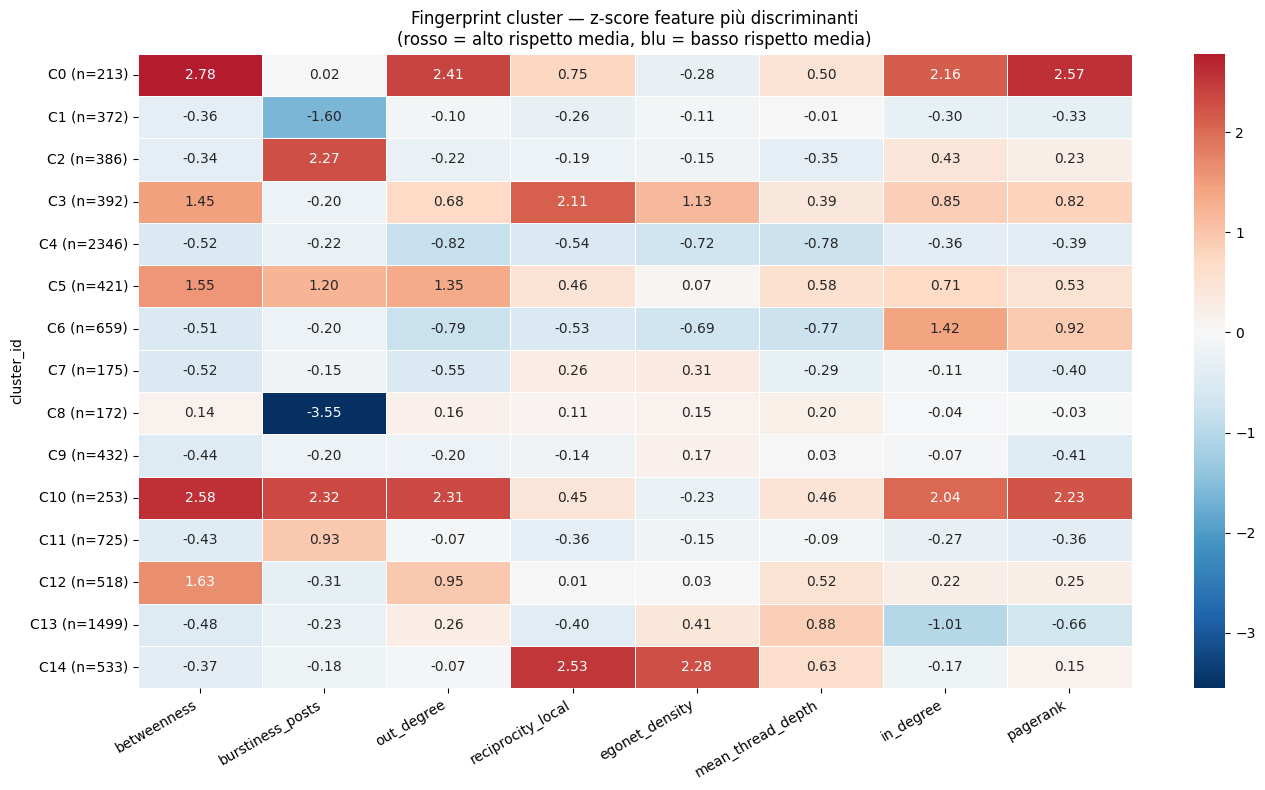

Figura salvata: 08_cluster_fingerprints.png


In [14]:
# Top-8 feature più discriminanti
top_features = df_importance.head(8)["feature"].tolist()
print(f"Top-8 feature discriminanti: {top_features}")

# Media per cluster
cluster_means = df_merged.groupby("cluster_id")[top_features].mean()

# Z-score rispetto alla media globale
global_mean = df_merged[top_features].mean()
global_std  = df_merged[top_features].std()
cluster_z   = (cluster_means - global_mean) / (global_std + 1e-9)

# Heatmap fingerprints
fig, ax = plt.subplots(figsize=(14, 8))
row_labels = [f"C{i} (n={cluster_df[cluster_df['cluster_id']==i].shape[0]})"
              for i in cluster_means.index]
sns.heatmap(cluster_z, ax=ax, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            xticklabels=top_features, yticklabels=row_labels,
            linewidths=0.5)
ax.set_title("Fingerprint cluster — z-score feature più discriminanti\n"
             "(rosso = alto rispetto media, blu = basso rispetto media)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_cluster_fingerprints.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata: 08_cluster_fingerprints.png")

In [15]:
# Naming suggerito per ogni cluster
print("=== FINGERPRINT TESTUALE — NAMING CLUSTER ===\n")
for cid in sorted(cluster_z.index):
    top_pos = cluster_z.loc[cid].nlargest(3).index.tolist()
    top_neg = cluster_z.loc[cid].nsmallest(2).index.tolist()
    n = cluster_df[cluster_df["cluster_id"]==cid].shape[0]
    z_pos = [f"{f}({cluster_z.loc[cid,f]:+.2f})" for f in top_pos]
    z_neg = [f"{f}({cluster_z.loc[cid,f]:+.2f})" for f in top_neg]
    print(f"C{cid:2d} (n={n:4d}): ALTO [{', '.join(z_pos)}] | BASSO [{', '.join(z_neg)}]")

=== FINGERPRINT TESTUALE — NAMING CLUSTER ===

C 0 (n= 213): ALTO [betweenness(+2.78), pagerank(+2.57), out_degree(+2.41)] | BASSO [egonet_density(-0.28), burstiness_posts(+0.02)]
C 1 (n= 372): ALTO [mean_thread_depth(-0.01), out_degree(-0.10), egonet_density(-0.11)] | BASSO [burstiness_posts(-1.60), betweenness(-0.36)]
C 2 (n= 386): ALTO [burstiness_posts(+2.27), in_degree(+0.43), pagerank(+0.23)] | BASSO [mean_thread_depth(-0.35), betweenness(-0.34)]
C 3 (n= 392): ALTO [reciprocity_local(+2.11), betweenness(+1.45), egonet_density(+1.13)] | BASSO [burstiness_posts(-0.20), mean_thread_depth(+0.39)]
C 4 (n=2346): ALTO [burstiness_posts(-0.22), in_degree(-0.36), pagerank(-0.39)] | BASSO [out_degree(-0.82), mean_thread_depth(-0.78)]
C 5 (n= 421): ALTO [betweenness(+1.55), out_degree(+1.35), burstiness_posts(+1.20)] | BASSO [egonet_density(+0.07), reciprocity_local(+0.46)]
C 6 (n= 659): ALTO [in_degree(+1.42), pagerank(+0.92), burstiness_posts(-0.20)] | BASSO [out_degree(-0.79), mean_threa

---
## Sezione 10 — Tabella sintesi e salvataggio

In [16]:
# Top-5 feature per eta-squared
top5_features = df_importance.head(5)[["feature", "H_stat", "p_value", "eta_squared"]].copy()
top5_features["p_value"] = top5_features["p_value"].apply(lambda p: f"{p:.2e}")

# Cluster con lift intra più alto
intra_lift = np.diag(lift_matrix)
top3_intra = np.argsort(intra_lift)[::-1][:3]

print(f"Assortatività r = {r:.4f}")
print(f"Rapporto intra/inter = {diag_mean/offdiag_mean:.2f}x")
print(f"NMI Louvain vs k-means = {nmi:.4f}")
print(f"Q Louvain = {Q_louvain:.4f} ({n_comm} community)")
print(f"\nTop-3 cluster con più omofilia conversazionale: {[f'C{i}' for i in top3_intra]}")
print(f"Intra-cluster lift: {[round(intra_lift[i],2) for i in top3_intra]}")

print("\nTop-5 feature discriminanti:")
print(top5_features.to_string(index=False))

Assortatività r = -0.0043
Rapporto intra/inter = 2.11x
NMI Louvain vs k-means = 0.0749
Q Louvain = 0.4173 (37 community)

Top-3 cluster con più omofilia conversazionale: ['C0', 'C10', 'C5']
Intra-cluster lift: [np.float64(480.17), np.float64(455.3), np.float64(20.07)]

Top-5 feature discriminanti:
          feature  H_stat  p_value  eta_squared
      betweenness  6625.3 0.00e+00       0.7280
 burstiness_posts  6415.2 0.00e+00       0.7049
       out_degree  6401.7 0.00e+00       0.7034
reciprocity_local  5948.6 0.00e+00       0.6535
   egonet_density  5843.7 0.00e+00       0.6420


In [17]:
# Salva results_rq_interpretive.md
lines = [
    "# Risultati Layer Interpretativi (nb08)\n",
    "\n## Layer 1 — Assortatività e flussi inter-cluster\n",
    "\n| Metrica | Valore |\n|---|---|\n",
    f"| Assortatività r (cluster_id) | {r:.4f} |\n",
    f"| Flusso medio intra-cluster | {diag_mean:.4f} |\n",
    f"| Flusso medio inter-cluster | {offdiag_mean:.4f} |\n",
    f"| Rapporto intra/inter | {diag_mean/offdiag_mean:.2f}x |\n",
    f"| Top-3 cluster più omilofi | {[f'C{i}' for i in top3_intra]} |\n",
    "\n## Layer 2 — NMI Louvain vs k-means\n",
    "\n| Metrica | Valore |\n|---|---|\n",
    f"| NMI (Louvain vs k-means) | {nmi:.4f} |\n",
    f"| Q Louvain conversazionale | {Q_louvain:.4f} |\n",
    f"| n_community Louvain | {n_comm} |\n",
    f"| n_cluster k-means | {N_CLUSTERS} |\n",
    f"| Nodi condivisi | {len(shared_nodes):,} |\n",
    "\n## Layer 3 — Feature importance (Kruskal-Wallis)\n",
    "\n",
    df_importance.to_markdown(index=False),
    "\n\n## Cluster fingerprints\n\n",
]

# Aggiungi fingerprint testuale
for cid in sorted(cluster_z.index):
    top_pos = cluster_z.loc[cid].nlargest(3).index.tolist()
    top_neg = cluster_z.loc[cid].nsmallest(2).index.tolist()
    n = cluster_df[cluster_df["cluster_id"]==cid].shape[0]
    z_pos_str = ", ".join([f"{f} ({cluster_z.loc[cid,f]:+.2f})" for f in top_pos])
    z_neg_str = ", ".join([f"{f} ({cluster_z.loc[cid,f]:+.2f})" for f in top_neg])
    lines.append(f"- **C{cid}** (n={n}): alto [{z_pos_str}] | basso [{z_neg_str}]\n")

with open("../docs/results_rq_interpretive.md", "w", encoding="utf-8") as f:
    f.writelines(lines)

print("Salvato: docs/results_rq_interpretive.md")

Salvato: docs/results_rq_interpretive.md


---
## Riepilogo risultati

| Layer | Metrica chiave | Interpretazione |
|---|---|---|
| Assortatività | r (vedi sopra) | >0.05 = omofilia, ~0 = ortogonale |
| Flussi intra/inter | rapporto (vedi sopra) | >1.5x = segregazione conversazionale |
| NMI | (vedi sopra) | 0.1–0.3 = parziale, >0.3 = forte |
| Feature importance | top feature per η² | Spiega "cosa distingue" ogni cluster |

**Narrativa tesi:**
- Se r>0 e NMI>0.1 → i cluster comportamentali sono anche strutturalmente distinti → coordinamento multi-dimensionale confermato
- Feature importance → naming cluster → Cap 5 più concreto e leggibile
- Flussi inter-cluster → chi parla con chi → pattern di interazione tra archetipi